In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath
from visualizations import flatmap_real_vals 

In [2]:
dataset_name = 'MDTB' # or Demand

projectPath, mainResultsPath = setProjectPath()
resultsPath = os.path.join(mainResultsPath, 'START_A2_gse_decomposition', dataset_name)
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
PKL_output = os.path.join(resultsPath, f'{dataset_name}_output.pkl') 

In [3]:
with open(PKL_output, 'rb') as pf:
    output = pickle.load(pf)

## visualize voxel-wise vs / (vs + vg) for the whole cortex

In [4]:
result = output['whole_cortex']['voxel_wise']   # columns in the order: vg, vs, ve 
voxel_wise_cortex = np.divide(result[:, 1].reshape((-1, 1)), np.sum(result[:, 0:2], axis=1, keepdims=True)) 

Text(0.5, 0.98, '$V_s/(V_s+V_g)$')

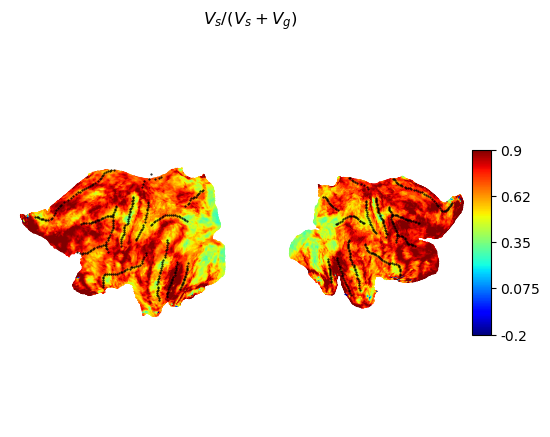

In [5]:
plt.subplot(1, 2, 1)
flatmap_real_vals(voxel_wise_cortex, hemi='L', cscale=[-0.2, 0.9], cmap='jet') 
plt.subplot(1, 2, 2)
flatmap_real_vals(voxel_wise_cortex, hemi='R', cscale=[-0.2, 0.9], cmap='jet', colorbar=True)  
plt.suptitle('$V_s/(V_s+V_g)$')
# plt.tight_layout()

## vs/(vs + vg) in whole cortex, PFC, visual, somatosensory and parietal regions

In [6]:
ROIs = ['whole_cortex', 'PFC', 'visual', 'somatosensory', 'parietal']
n_rois = len(ROIs)
props = [] 

for roiI in np.arange(n_rois):
    result = output[ROIs[roiI]]['global'].flatten() 
    prop = result[1]/(result[0]+result[1]) 
    props.append(prop) 

props = np.array(props) 

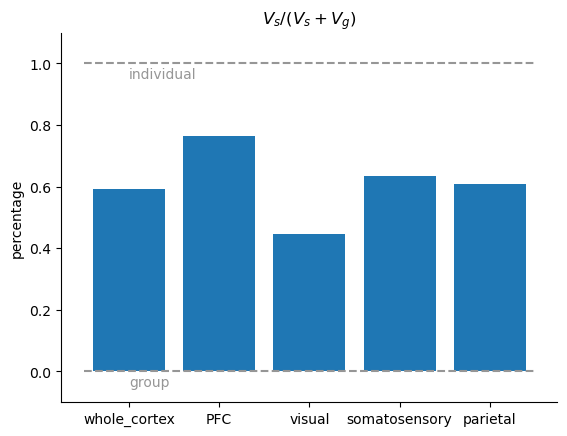

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=1) 

ax.bar(np.arange(n_rois), props) 
ax.set_xticks(np.arange(n_rois), labels=ROIs)
ax.set_ylabel('percentage') 
ax.set_ylim([-0.1, 1.1])
ax.set_yticks(np.arange(0, 1.1, 0.2)) 
ax.hlines(y=0, xmin=-0.5, xmax=n_rois-0.5, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.hlines(y=1, xmin=-0.5, xmax=n_rois-0.5, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.text(0, -0.05, 'group', color=(150/255, 150/255, 150/255))
ax.text(0, 0.95, 'individual', color=(150/255, 150/255, 150/255))
ax.set_title('$V_s/(V_s + V_g)$') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

JPG_fig = os.path.join(resultsPath, f'variance_decomposition_bar_plot.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 

In PFC, group variance accounts for 24% out of total explainable variance, while individual variance accounts for 76%. 